In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import warnings 
warnings.filterwarnings("ignore")

In [2]:
from DFTStructureGenerator import B_N_Cl
import numpy as np
import pickle

In [3]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import KFold, cross_val_score
from catboost import CatBoostRegressor, CatBoostClassifier
from matplotlib import pyplot as plt


In [4]:
# PhysOrg
all_descriptors_names = [
    "C_Cl react deltaG", "C_Cl Cl_charge", "C_Cl C_charge", "C_Cl Cl_Hirshfield_charge", "C_Cl C_Hirshfield_charge", 
    "C_Cl MaxOtherCharge", "C_Cl MinOtherCharge", "C_Cl MaxChargeDist", "C_Cl MinOtherChargeDist", 
    "C_Cl MaxOtherHCharge", "C_Cl MinOtherHCharge", "C_Cl MaxHChargeDist", "C_Cl MinHOtherChargeDist", 
    "C_Cl MaxAromaticRingCharge", "C_Cl MinAromaticRingCharge", "C_Cl MaxAromaticChargeDist", "C_Cl MinAromaticChargeDist",
    "C_Cl C_Cl_dist", 
    "C_Cl HOMO-1", "C_Cl HOMO", "C_Cl LUMO", "C_Cl LUMO+1", "C_Cl dipole", "C_Cl Bv2radius", "C_Cl Bv4radius", "C_Cl Bv6radius", "C C_charge", "C C_spin", "C C_Hirshfield_charge", 
    "C Alpha-HOMO-1", "C Alpha-HOMO", "C Alpha-LUMO", "C Alpha-LUMO+1", "C Beta-HOMO-1", "C Beta-HOMO", "C Beta-LUMO", "C Beta-LUMO+1", "C_dipole",
    
    "B_G", "B_HOMO-1", "B_HOMO", "B_LUMO", "B_LUMO+1", "B_HOMO-1_B", "B_HOMO_B", "B_LUMO_B", "B_LUMO+1_B", "B_dipole", "B_spin",
    # "B_Cl_G", "B_Cl_HOMO-1", "B_Cl_HOMO", "B_Cl_LUMO", "B_Cl_LUMO+1", "B_Cl_dipole", "B_Cl_Charge_B", "B_Cl_Charge_Cl", "B_Cl_Bond_B_Cl", "B_Cl_BV_2A", "B_Cl_BV_4A", "B_Cl_BV_6A",
    
    "Ini_G", "Ini_HOMO-1", "Ini_HOMO", "Ini_LUMO", "Ini_LUMO+1", "Ini_dipole", "Ini_T","Ini_Charge_N", "Ini_Charge_C", "Ini_Bond_N_C", "Ini_BV_2A", "Ini_BV_4A", "Ini_BV_6A",
    "Sol_G", "Sol_HOMO-1", "Sol_HOMO", "Sol_LUMO", "Sol_LUMO+1", "Sol_dipole", "Sol_x",
    "S_G", "S_HOMO-1", "S_HOMO", "S_LUMO", "S_LUMO+1", "S_dipole", "S_Charge_S", "S_Charge_C", "S_Bond_S_C", "S_BV_2A", "S_BV_4A", "S_BV_6A",
    "B_eq",
    ]
len(all_descriptors_names)

82

# 1.Load Descritpors

In [5]:
with open("Data/Cldes_new.pkl", 'rb') as f:
    Cl_des_map = pickle.load(f)

In [6]:
with open("Data/Fingerprint.pkl", 'rb') as f:
    index_map = pickle.load(f)

In [7]:
with open("Data/PhysOrgdes_new.pkl", 'rb') as f:
    index_map = pickle.load(f)

In [8]:
all_X_qm, yields = B_N_Cl.descriptor_generator("Data/Iteration/Result_sum_00022.xlsx", index_map, Cl_des_map)
all_X_qm.shape

(257, 82)

# 3. Model Performance

## 3.1Regressor

array([[6.70811000e-01, 2.65547982e-02, 4.77804812e+00, ...,
        1.09943182e+02, 1.99397927e+01, 1.50000000e+00],
       [6.70811000e-01, 2.65547982e-02, 4.77804812e+00, ...,
        1.10072314e+02, 1.98932406e+01, 2.00000000e+00],
       [6.70811000e-01, 2.65547982e-02, 4.77804812e+00, ...,
        1.10072314e+02, 1.98932406e+01, 2.50000000e+00],
       ...,
       [2.38870000e-02, 3.19646024e-02, 4.68590466e+00, ...,
        1.23243802e+02, 3.74806033e+01, 3.00000000e+00],
       [2.38870000e-02, 3.19646024e-02, 4.68590466e+00, ...,
        1.23243802e+02, 3.74806033e+01, 1.50000000e+00],
       [2.38870000e-02, 3.19646024e-02, 4.68590466e+00, ...,
        1.23243802e+02, 3.74806033e+01, 3.00000000e+00]])

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=1)
all_X = all_X_qm
# all_X = X_selected.to_numpy()
# all_X = np.concatenate([all_X_mf, all_X_qm], axis=1)
all_r2s, all_f1s, all_acc, all_preds = [], [], [], np.zeros(len(all_X))
result_matrix = np.zeros((2, 2))
target = yields
for train_ids, test_ids in kf.split(all_X):
    model = CatBoostRegressor(iterations=10000, random_seed=0, verbose=0, depth=2)
    model.fit(all_X[train_ids], target[train_ids])
    pred = model.predict(all_X[test_ids])
    r2 = r2_score(target[test_ids], pred)
    all_r2s.append(r2)
    print("R2: ", r2)
    a = target[test_ids] > 20
    b = pred > 20
    r2 = accuracy_score(a,b)
    print("Accuracy: ", r2)
    all_acc.append(r2)
    r2 = f1_score(a,b)
    print("F1: ",r2)
    all_f1s.append(r2)
    result_matrix += confusion_matrix(a,b)
    all_preds[test_ids] = pred
print(np.mean(all_r2s))


R2:  0.6545483454957209
Accuracy:  0.8269230769230769
F1:  0.8615384615384616
R2:  0.7864946262816591
Accuracy:  0.8846153846153846
F1:  0.911764705882353
R2:  0.5167544083558675
Accuracy:  0.8627450980392157
F1:  0.9041095890410958
R2:  0.7914970423576853
Accuracy:  0.8627450980392157
F1:  0.9014084507042254
R2:  0.755700022397729
Accuracy:  0.9019607843137255
F1:  0.9295774647887323
0.7009988889777323


In [ ]:
0.718

## 3.2 Classifier

In [27]:
kf = KFold(n_splits=5, shuffle=True, random_state=1)
all_X = all_X_qm
# all_X = np.concatenate([all_X_mf, all_X_qm], axis=1)
all_f1s, all_acc, all_preds = [], [], np.zeros(len(all_X))
result_matrix = np.zeros((2, 2))
target = np.array([1 if each > 20 else 0 for each in yields])
for train_ids, test_ids in kf.split(all_X):
    # model = RandomForestClassifier(n_estimators=200, random_state=0)
    # model = XGBClassifier(n_estimators=100, random_state=0)
    # model = GradientBoostingClassifier(n_estimators=200, random_state=0)
    model = CatBoostClassifier(iterations=10000, random_seed=0, verbose=0, depth=2)
    model.fit(all_X[train_ids], target[train_ids])
    pred = model.predict(all_X[test_ids])
    r2 = accuracy_score(target[test_ids], pred)
    print("Accuracy: ", r2)
    all_acc.append(r2)
    r2 = f1_score(target[test_ids], pred)
    print("F1: ",r2)
    all_f1s.append(r2)
    result_matrix += confusion_matrix(target[test_ids], pred)
    
    all_preds[test_ids] = pred
result_matrix = result_matrix / 4
print(np.mean(all_acc), np.mean(all_f1s))


Accuracy:  0.8269230769230769
F1:  0.8615384615384616
Accuracy:  0.9038461538461539
F1:  0.9253731343283582
Accuracy:  0.803921568627451
F1:  0.8571428571428571
Accuracy:  0.9019607843137255
F1:  0.927536231884058
Accuracy:  0.9215686274509803
F1:  0.9444444444444445
0.8716440422322774 0.9032070258676359


# 4. Feature Importance

## 4.0 Feature Selection Before Importance

In [9]:
all_X_qm, yields = B_N_Cl.descriptor_generator("Data/Iteration/Result_sum_00022.xlsx", index_map, Cl_des_map)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor  
from sklearn.model_selection import train_test_split

def select_features_based_on_correlation_and_importance(X, y, correlation_threshold=0.9, model=None):
    if model is None:
        model = CatBoostRegressor(iterations=10000, random_seed=0, verbose=0, depth=2)
        model.fit(X, y)
    feature_importances = pd.Series(model.feature_importances_, index=X.columns)
    print("特征重要性：\n", feature_importances.sort_values(ascending=False))
    
    corr_matrix = X.corr().abs()
    
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = set()
    
    for column in upper_tri.columns:
        for row in upper_tri.index:
            if upper_tri.loc[row, column] > correlation_threshold:
                if feature_importances[row] > feature_importances[column]:
                    to_drop.add(column)
                else:
                    to_drop.add(row)
    
    selected_features = [col for col in X.columns if col not in to_drop]
    
    
    X_selected = X[selected_features]
    
    return selected_features, X_selected

In [ ]:
selected_features, X_selected = select_features_based_on_correlation_and_importance(pd.DataFrame(all_X_qm), yields)

In [ ]:
B_N_Cl.draw_correlation_map(X_selected.to_numpy(), y=yields, save_name='test', useSVG=1, figure_size=(7,5), annot=False, show_label=True)

## 4.1 Model Feature Importance

In [27]:
len([
    "C_Cl react deltaG", "C_Cl Cl_charge", "C_Cl C_charge", "C_Cl Cl_Hirshfield_charge", "C_Cl C_Hirshfield_charge", 
    "C_Cl MaxOtherCharge", "C_Cl MinOtherCharge", "C_Cl MaxChargeDist", "C_Cl MinOtherChargeDist", 
    "C_Cl MaxOtherHCharge", "C_Cl MinOtherHCharge", "C_Cl MaxHChargeDist", "C_Cl MinHOtherChargeDist", 
    "C_Cl MaxAromaticRingCharge", "C_Cl MinAromaticRingCharge", "C_Cl MaxAromaticChargeDist", "C_Cl MinAromaticChargeDist",
    "C_Cl C_Cl_dist", 
    "C_Cl HOMO-1", "C_Cl HOMO", "C_Cl LUMO", "C_Cl LUMO+1", "C_Cl dipole", "C_Cl Bv2radius", "C_Cl Bv4radius", "C_Cl Bv6radius", "C C_charge", "C C_spin", "C C_Hirshfield_charge", 
    "C Alpha-HOMO-1", "C Alpha-HOMO", "C Alpha-LUMO", "C Alpha-LUMO+1", "C Beta-HOMO-1", "C Beta-HOMO", "C Beta-LUMO", "C Beta-LUMO+1", "C_dipole",])

38

In [12]:
# PhysOrg
all_descriptors_names = np.array([
    "C_Cl react deltaG", "C_Cl Cl_charge", "C_Cl C_charge", "C_Cl Cl_Hirshfield_charge", "C_Cl C_Hirshfield_charge", 
    "C_Cl MaxOtherCharge", "C_Cl MinOtherCharge", "C_Cl MaxChargeDist", "C_Cl MinOtherChargeDist", 
    "C_Cl MaxOtherHCharge", "C_Cl MinOtherHCharge", "C_Cl MaxHChargeDist", "C_Cl MinHOtherChargeDist", 
    "C_Cl MaxAromaticRingCharge", "C_Cl MinAromaticRingCharge", "C_Cl MaxAromaticChargeDist", "C_Cl MinAromaticChargeDist",
    "C_Cl C_Cl_dist", 
    "C_Cl HOMO-1", "C_Cl HOMO", "C_Cl LUMO", "C_Cl LUMO+1", "C_Cl dipole", "C_Cl Bv2radius", "C_Cl Bv4radius", "C_Cl Bv6radius", "C C_charge", "C C_spin", "C C_Hirshfield_charge", 
    "C Alpha-HOMO-1", "C Alpha-HOMO", "C Alpha-LUMO", "C Alpha-LUMO+1", "C Beta-HOMO-1", "C Beta-HOMO", "C Beta-LUMO", "C Beta-LUMO+1", "C_dipole",
    
    "B_G", "B_HOMO-1", "B_HOMO", "B_LUMO", "B_LUMO+1", "B_HOMO-1_B", "B_HOMO_B", "B_LUMO_B", "B_LUMO+1_B", "B_dipole", "B_spin",
    # "B_Cl_G", "B_Cl_HOMO-1", "B_Cl_HOMO", "B_Cl_LUMO", "B_Cl_LUMO+1", "B_Cl_dipole", "B_Cl_Charge_B", "B_Cl_Charge_Cl", "B_Cl_Bond_B_Cl", "B_Cl_BV_2A", "B_Cl_BV_4A", "B_Cl_BV_6A",
    
    "Ini_G", "Ini_HOMO-1", "Ini_HOMO", "Ini_LUMO", "Ini_LUMO+1", "Ini_dipole", "Ini_T","Ini_Charge_N", "Ini_Charge_C", "Ini_Bond_N_C", "Ini_BV_2A", "Ini_BV_4A", "Ini_BV_6A",
    "Sol_G", "Sol_HOMO-1", "Sol_HOMO", "Sol_LUMO", "Sol_LUMO+1", "Sol_dipole", "Sol_x",
    "S_G", "S_HOMO-1", "S_HOMO", "S_LUMO", "S_LUMO+1", "S_dipole", "S_Charge_S", "S_Charge_C", "S_Bond_S_C", "S_BV_2A", "S_BV_4A", "S_BV_6A",
    "B_eq",
    ])
print(all_descriptors_names[selected_features])

['C_Cl C_charge' 'C_Cl C_Hirshfield_charge' 'C_Cl MinAromaticChargeDist'
 'B_G' 'B_HOMO' 'B_LUMO_B' 'B_LUMO+1_B' 'B_dipole' 'B_spin' 'Ini_G'
 'Ini_HOMO-1' 'Ini_HOMO' 'Ini_LUMO' 'Ini_LUMO+1' 'Ini_dipole' 'Ini_T'
 'Ini_Charge_N' 'Ini_Charge_C' 'Ini_Bond_N_C' 'Ini_BV_2A' 'Ini_BV_6A'
 'Sol_G' 'Sol_HOMO' 'Sol_LUMO' 'Sol_LUMO+1' 'Sol_dipole' 'Sol_x' 'S_G'
 'S_HOMO-1' 'S_HOMO' 'S_dipole' 'S_Charge_S' 'S_Charge_C' 'S_Bond_S_C'
 'S_BV_2A' 'S_BV_4A' 'B_eq']


In [14]:
model = CatBoostRegressor(iterations=10000, random_seed=0, verbose=0, depth=2)
model.fit(X_selected, yields)
importance = model.feature_importances_
np.array(all_descriptors_names[selected_features])[np.argsort(importance)[::-1]]


array(['B_spin', 'C_Cl C_charge', 'C_Cl MinAromaticChargeDist',
       'C_Cl C_Hirshfield_charge', 'Sol_dipole', 'Sol_x', 'Ini_HOMO',
       'Ini_LUMO+1', 'B_HOMO', 'Ini_T', 'Sol_LUMO+1', 'Sol_G', 'B_LUMO_B',
       'Sol_HOMO', 'B_eq', 'B_G', 'Ini_Charge_C', 'Ini_Charge_N', 'Ini_G',
       'S_Charge_C', 'S_Bond_S_C', 'S_dipole', 'B_dipole', 'Ini_BV_6A',
       'B_LUMO+1_B', 'Sol_LUMO', 'S_HOMO-1', 'Ini_BV_2A', 'S_G',
       'Ini_LUMO', 'S_Charge_S', 'Ini_dipole', 'S_HOMO', 'Ini_HOMO-1',
       'S_BV_2A', 'S_BV_4A', 'Ini_Bond_N_C'], dtype='<U26')

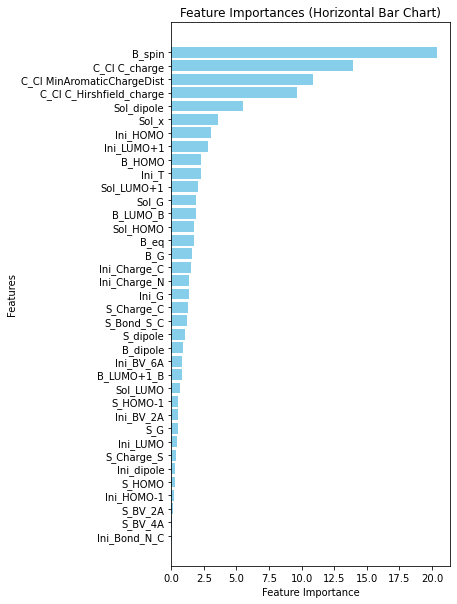

In [37]:
plt.figure(figsize=(5,10))
plt.barh(np.array(all_descriptors_names[selected_features])[np.argsort(importance)], np.sort(importance), color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importances (Horizontal Bar Chart)')
plt.savefig("Figure/Feature_Importance.png", dpi=300, bbox_inches='tight')

## 4.2 PYSR

In [ ]:
from pysr import PySRRegressor

model = PySRRegressor(
    maxsize=20,
    niterations=40,  # < Increase me for better results
    binary_operators=["+", "*"],
    unary_operators=[
        "cos",
        "exp",
        "sin",
        "inv(x) = 1/x",
        # ^ Custom operator (julia syntax)
    ],
    extra_sympy_mappings={"inv": lambda x: 1 / x},
    # ^ Define operator for SymPy as well
    elementwise_loss="loss(prediction, target) = (prediction - target)^2",
    # ^ Custom loss function (julia syntax)
)

In [ ]:
model.fit(all_X_qm[:,np.argsort(importance)[::-1][:15]], yields)

In [ ]:
plt.scatter(model.predict(all_X_qm[:,np.argsort(importance)[::-1][:15]], 13), yields)

In [ ]:
r2_score(model.predict(all_X_qm[:,np.argsort(importance)[::-1][:15]], 13), yields)

## 4.3 Feature Selection by Performance

In [23]:
from copy import deepcopy
def feature_selection(X, y, train, test):
    remain_list = []
    all_list = list(range(len(X[0])))
    #removed_lists = Bayesian_Optimization.index_of_highly_correlated_features(X, threshold=0.98)
    for idx in range(len(X[0])):
        all_r2 = []
        for id, each in enumerate(all_list):
            print(id, len(all_list), end='\r')
            if each in remain_list:
                all_r2.append(-10)
                continue
            else:
                temp_remain_list = remain_list + [each]
            X_new = X[:, temp_remain_list]
            temp_r2 = []
            kfold = KFold(n_splits=5, shuffle=True, random_state=0)
            model = CatBoostRegressor(iterations=100, random_seed=0, verbose=0, depth=2)
            acc = cross_val_score(model, X_new[train], y[train], cv=kfold, n_jobs=1).mean()
            temp_r2 = acc.mean()
            all_r2.append(temp_r2)
        max_id = np.argmax(all_r2)
        if max_id in remain_list:
            remain_list.remove(max_id)
        else:
            remain_list.append(max_id)
        print(np.max(all_r2), remain_list)
    return all_r2, remain_list
all_r2, y_in_removed_lists = feature_selection(X_selected.to_numpy(), yields, np.arange(len(X_selected)), [])

0.3421171564042128 [7]
0.5047251042180285 [7, 17]
0.5785442084673169 [7, 17, 0]
0.628982881090377 [7, 17, 0, 24]
0.6766977850525302 [7, 17, 0, 24, 4]
0.7022620435600583 [7, 17, 0, 24, 4, 9]
0.7107384912137731 [7, 17, 0, 24, 4, 9, 11]
0.7125774881786242 [7, 17, 0, 24, 4, 9, 11, 30]
0.718291191727533 [7, 17, 0, 24, 4, 9, 11, 30, 2]
0.72011712778063 [7, 17, 0, 24, 4, 9, 11, 30, 2, 8]
0.7177082606935354 [7, 17, 0, 24, 4, 9, 11, 30, 2, 8, 21]
0.7142756945884859 [7, 17, 0, 24, 4, 9, 11, 30, 2, 8, 21, 20]
0.7101683565431897 [7, 17, 0, 24, 4, 9, 11, 30, 2, 8, 21, 20, 25]
0.7133591139208002 [7, 17, 0, 24, 4, 9, 11, 30, 2, 8, 21, 20, 25, 6]
0.7192313158372448 [7, 17, 0, 24, 4, 9, 11, 30, 2, 8, 21, 20, 25, 6, 28]
0.7107493399651219 [7, 17, 0, 24, 4, 9, 11, 30, 2, 8, 21, 20, 25, 6, 28, 1]
0.7181338954966906 [7, 17, 0, 24, 4, 9, 11, 30, 2, 8, 21, 20, 25, 6, 28, 1, 12]
0.7213005251082434 [7, 17, 0, 24, 4, 9, 11, 30, 2, 8, 21, 20, 25, 6, 28, 1, 12, 26]
0.7168305799358836 [7, 17, 0, 24, 4, 9, 11, 30, 

In [24]:
all_descriptors_names[selected_features][[[7, 17, 0, 24, 4, 9, 11, 30, 2, 8, 21, 20, 25, 6, 28, 1, 12, 26, 13, 10]]]

array(['B_dipole', 'Ini_Charge_C', 'C_Cl C_charge', 'Sol_LUMO+1',
       'B_HOMO', 'Ini_G', 'Ini_HOMO', 'S_dipole',
       'C_Cl MinAromaticChargeDist', 'B_spin', 'Sol_G', 'Ini_BV_6A',
       'Sol_dipole', 'B_LUMO+1_B', 'S_HOMO-1', 'C_Cl C_Hirshfield_charge',
       'Ini_LUMO', 'Sol_x', 'Ini_LUMO+1', 'Ini_HOMO-1'], dtype='<U26')